In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import sklearn.preprocessing
from sklearn.metrics import r2_score,root_mean_squared_error,mean_squared_error

from keras.layers import Dense,Dropout,SimpleRNN,LSTM
from keras.models import Sequential



In [3]:

df=pd.read_csv('DOM_hourly.csv')
df.head()

,Datetime,DOM_MW
0,2005-12-31 01:00:00,9389.0
1,2005-12-31 02:00:00,9070.0
2,2005-12-31 03:00:00,9001.0
3,2005-12-31 04:00:00,9042.0
4,2005-12-31 05:00:00,9132.0


In [4]:
# df = df.set_index('Datetime')
# df.index = pd.to_datetime(df.index)
# df

In [5]:
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)


df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
# df['quarter'] = df.index.quarter
df['month'] = df.index.month
# df['year'] = df.index.year
# df['dayofyear'] = df.index.dayofyear
# df['dayofmonth'] = df.index.day
# df['weekofyear'] = df.index.isocalendar().week.astype(int)
df

,DOM_MW,hour,dayofweek,month
Datetime,,,,
2005-12-31 01:00:00,9389.0,1,5,12
2005-12-31 02:00:00,9070.0,2,5,12
2005-12-31 03:00:00,9001.0,3,5,12
2005-12-31 04:00:00,9042.0,4,5,12
2005-12-31 05:00:00,9132.0,5,5,12
...,...,...,...,...
2018-01-01 20:00:00,18418.0,20,0,1
2018-01-01 21:00:00,18567.0,21,0,1
2018-01-01 22:00:00,18307.0,22,0,1


In [6]:
df

,DOM_MW,hour,dayofweek,month
Datetime,,,,
2005-12-31 01:00:00,9389.0,1,5,12
2005-12-31 02:00:00,9070.0,2,5,12
2005-12-31 03:00:00,9001.0,3,5,12
2005-12-31 04:00:00,9042.0,4,5,12
2005-12-31 05:00:00,9132.0,5,5,12
...,...,...,...,...
2018-01-01 20:00:00,18418.0,20,0,1
2018-01-01 21:00:00,18567.0,21,0,1
2018-01-01 22:00:00,18307.0,22,0,1


In [7]:
# import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [8]:
# df.groupby('month')['DOM_MW'].mean().plot()

In [9]:
def normalize_data(df):
    scaler = sklearn.preprocessing.MinMaxScaler()
    df['DOM_MW']=scaler.fit_transform(df['DOM_MW'].values.reshape(-1,1))
    return df

df_norm = normalize_data(df)
df_norm.shape
df

,DOM_MW,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
Datetime,,,,,,,,,,
2005-12-31 01:00:00,0.398863,1,5,12,0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000
2005-12-31 02:00:00,0.383224,2,5,12,0.500000,0.866025,-0.974928,-0.222521,-2.449294e-16,1.000000
2005-12-31 03:00:00,0.379841,3,5,12,0.707107,0.707107,-0.974928,-0.222521,-2.449294e-16,1.000000
2005-12-31 04:00:00,0.381851,4,5,12,0.866025,0.500000,-0.974928,-0.222521,-2.449294e-16,1.000000
2005-12-31 05:00:00,0.386263,5,5,12,0.965926,0.258819,-0.974928,-0.222521,-2.449294e-16,1.000000
...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,0.841504,20,0,1,-0.866025,0.500000,0.000000,1.000000,5.000000e-01,0.866025
2018-01-01 21:00:00,0.848809,21,0,1,-0.707107,0.707107,0.000000,1.000000,5.000000e-01,0.866025
2018-01-01 22:00:00,0.836062,22,0,1,-0.500000,0.866025,0.000000,1.000000,5.000000e-01,0.866025


In [10]:
df['rolling'] = df.DOM_MW.rolling(24).mean()
df['rolling']  = df['rolling'].bfill()
df

,DOM_MW,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,rolling
Datetime,,,,,,,,,,,
2005-12-31 01:00:00,0.398863,1,5,12,0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,0.430342
2005-12-31 02:00:00,0.383224,2,5,12,0.500000,0.866025,-0.974928,-0.222521,-2.449294e-16,1.000000,0.430342
2005-12-31 03:00:00,0.379841,3,5,12,0.707107,0.707107,-0.974928,-0.222521,-2.449294e-16,1.000000,0.430342
2005-12-31 04:00:00,0.381851,4,5,12,0.866025,0.500000,-0.974928,-0.222521,-2.449294e-16,1.000000,0.430342
2005-12-31 05:00:00,0.386263,5,5,12,0.965926,0.258819,-0.974928,-0.222521,-2.449294e-16,1.000000,0.430342
...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,0.841504,20,0,1,-0.866025,0.500000,0.000000,1.000000,5.000000e-01,0.866025,0.785943
2018-01-01 21:00:00,0.848809,21,0,1,-0.707107,0.707107,0.000000,1.000000,5.000000e-01,0.866025,0.785771
2018-01-01 22:00:00,0.836062,22,0,1,-0.500000,0.866025,0.000000,1.000000,5.000000e-01,0.866025,0.785543


In [11]:
# df.drop(['hour','dayofweek','month'], axis=1, inplace=True)

In [12]:
#checking missing data
df.isna().sum()

DOM_MW       0
hour         0
dayofweek    0
month        0
hour_sin     0
hour_cos     0
dow_sin      0
dow_cos      0
month_sin    0
month_cos    0
rolling      0
dtype: int64

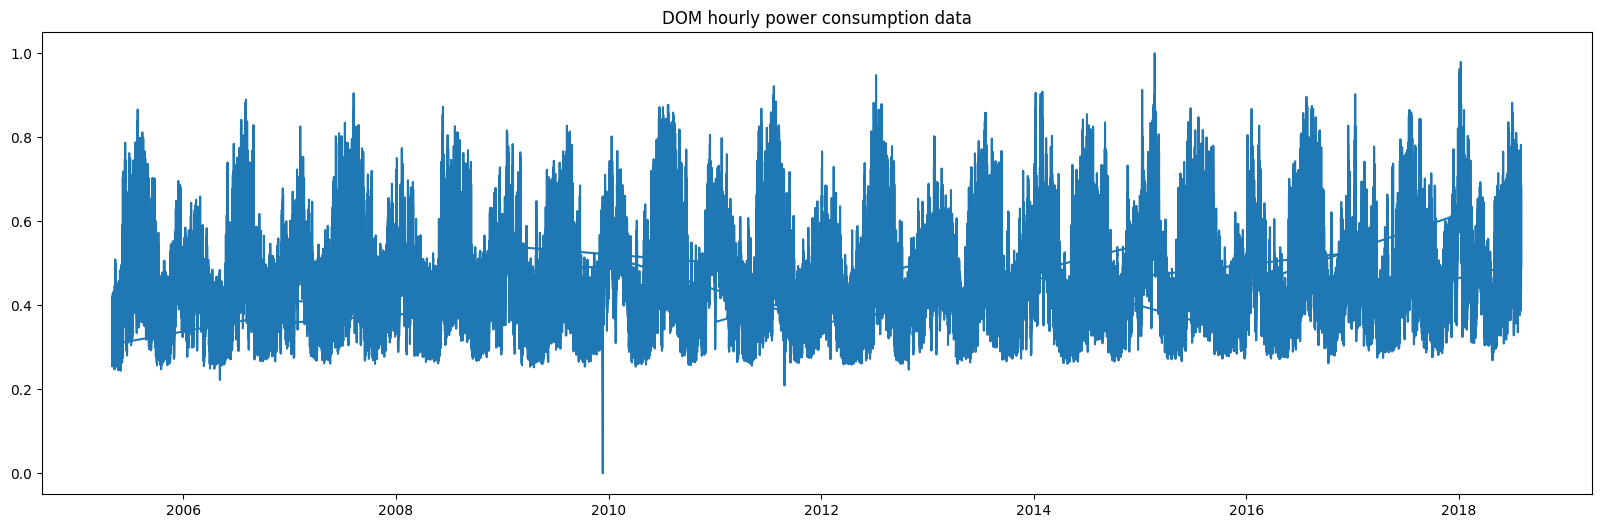

In [13]:
# df.plot(figsize=(16,4),legend=True)
plt.figure(figsize=(20,6)) 
plt.plot(df.index,df['DOM_MW'])
plt.title('DOM hourly power consumption data')

plt.show()

In [14]:
df_norm.shape

(116189, 11)

In [15]:
def load_data(df, seq_len, target_col, split_ratio=0.8):
    
    X = []
    y = []
    
    data = df.values  
    target_index = df.columns.get_loc(target_col)
    

    for i in range(seq_len, len(df)):
        X.append(data[i-seq_len:i])          # all features
        y.append(data[i, target_index])      # only target
    
    X = np.array(X)
    y = np.array(y)
    
    split = int(split_ratio * len(X))
    
    X_train = X[:split]
    y_train = y[:split]
    
    X_test = X[split:]
    y_test = y[split:]
    
    return X_train, y_train, X_test, y_test

In [16]:
#create train, test data
seq_len = 24

X_train, y_train, X_test, y_test = load_data(df, seq_len,'DOM_MW')

print('X_train.shape = ',X_train.shape)
print('y_train.shape = ', y_train.shape)
print('X_test.shape = ', X_test.shape)
print('y_test.shape = ',y_test.shape)

X_train.shape =  (92932, 24, 11)
y_train.shape =  (92932,)
X_test.shape =  (23233, 24, 11)
y_test.shape =  (23233,)


In [17]:


n_features = X_train.shape[2]  

rnn_model = Sequential()

# Layer 1
rnn_model.add(SimpleRNN(
    40,
    activation="tanh",
    return_sequences=True,
    input_shape=(X_train.shape[1], n_features)
))
rnn_model.add(Dropout(0.15))

# Layer 2
rnn_model.add(SimpleRNN(
    40,
    activation="tanh",
    return_sequences=True
))
rnn_model.add(Dropout(0.15))

# Layer 3
rnn_model.add(SimpleRNN(
    40,
    activation="tanh",
    return_sequences=False
))
rnn_model.add(Dropout(0.15))

# Output
rnn_model.add(Dense(1))

rnn_model.summary()

c:\Users\Admin\.conda\envs\energy\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 24, 40)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 24, 40)         │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,601 (33.60 KB)

 Trainable params: 8,601 (33.60 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
rnn_model.compile(optimizer="adam",loss="MSE")
rnn_model.fit(X_train, y_train, epochs=5,batch_size=128)


Epoch 1/5
727/727 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - loss: 0.0634
Epoch 2/5
727/727 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 0.0092
Epoch 3/5
727/727 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.0039
Epoch 4/5
727/727 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - loss: 0.0028
Epoch 5/5
727/727 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0024


In [19]:
rnn_predictions = rnn_model.predict(X_test)

rnn_score = r2_score(y_test,rnn_predictions)
print("R2 Score of RNN model = ",rnn_score)

727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
R2 Score of RNN model =  0.8534402665794764


0.9524

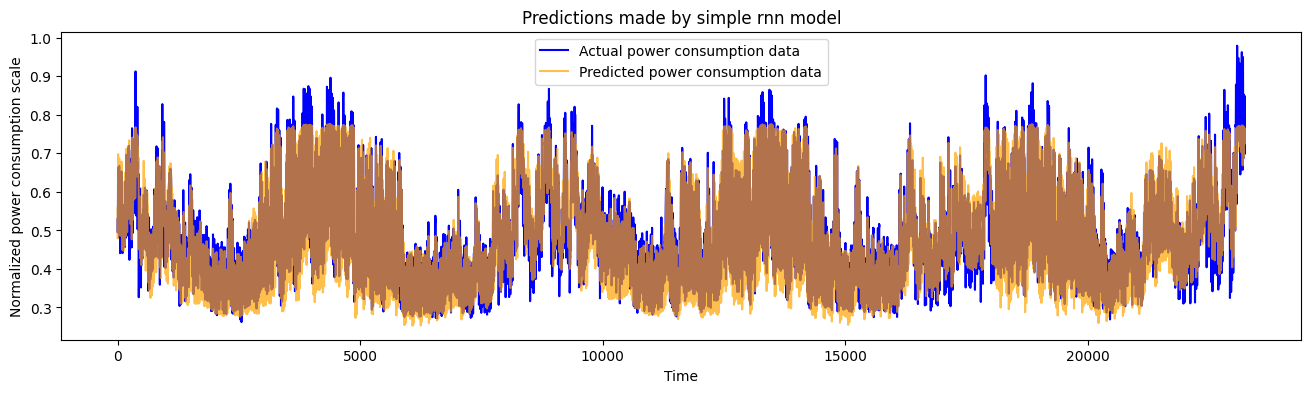

In [20]:
def plot_predictions(test, predicted, title):
    plt.figure(figsize=(16,4))
    plt.plot(test, color='blue',label='Actual power consumption data')
    plt.plot(predicted, alpha=0.7, color='orange',label='Predicted power consumption data')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Normalized power consumption scale')
    plt.legend()
    plt.show()
    
plot_predictions(y_test, rnn_predictions, "Predictions made by simple rnn model")

In [21]:
lstm_model = Sequential()

lstm_model.add(LSTM(40,activation="tanh",recurrent_activation='sigmoid',return_sequences=True, input_shape=(X_train.shape[1],n_features)))
lstm_model.add(Dropout(0.15))

lstm_model.add(LSTM(40,activation="tanh",recurrent_activation='sigmoid',return_sequences=True))
lstm_model.add(Dropout(0.15))

lstm_model.add(LSTM(40,activation="tanh",recurrent_activation='sigmoid',return_sequences=False))
lstm_model.add(Dropout(0.15))

lstm_model.add(Dense(1))

lstm_model.summary()

c:\Users\Admin\.conda\envs\energy\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 40)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 40)         │        12,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 40)             │        12,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,281 (133.91 KB)

 Trainable params: 34,281 (133.91 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
lstm_model.compile(optimizer="adam",loss="MSE")
lstm_model.fit(X_train, y_train, epochs=10, batch_size=128)

Epoch 1/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - loss: 0.0069
Epoch 2/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.0029
Epoch 3/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - loss: 0.0023
Epoch 4/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - loss: 0.0018
Epoch 5/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - loss: 0.0014
Epoch 6/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - loss: 0.0011
Epoch 7/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - loss: 8.7706e-04
Epoch 8/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - loss: 7.2349e-04
Epoch 9/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - loss: 6.0402e-04
Epoch 10/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - loss: 5.0456e-04


In [23]:
lstm_predictions = lstm_model.predict(X_test)

lstm_score = r2_score(y_test, lstm_predictions)
print("R^2 Score of LSTM model = ",lstm_score)

727/727 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
R^2 Score of LSTM model =  0.9733573307772269


In [24]:
x_train_pred = lstm_model.predict(X_train)
lstm_train_score = r2_score(y_train,x_train_pred)
lstm_train_score

2905/2905 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step


0.9769149142654919

In [25]:
ans = root_mean_squared_error(y_test, lstm_predictions)
ans

0.019885813524456834

In [26]:
ans1 = root_mean_squared_error(y_train,x_train_pred)
ans1

0.0177958431306595

In [27]:
score = np.sqrt(mean_squared_error(y_test, lstm_predictions))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 0.02


0.9769

shap


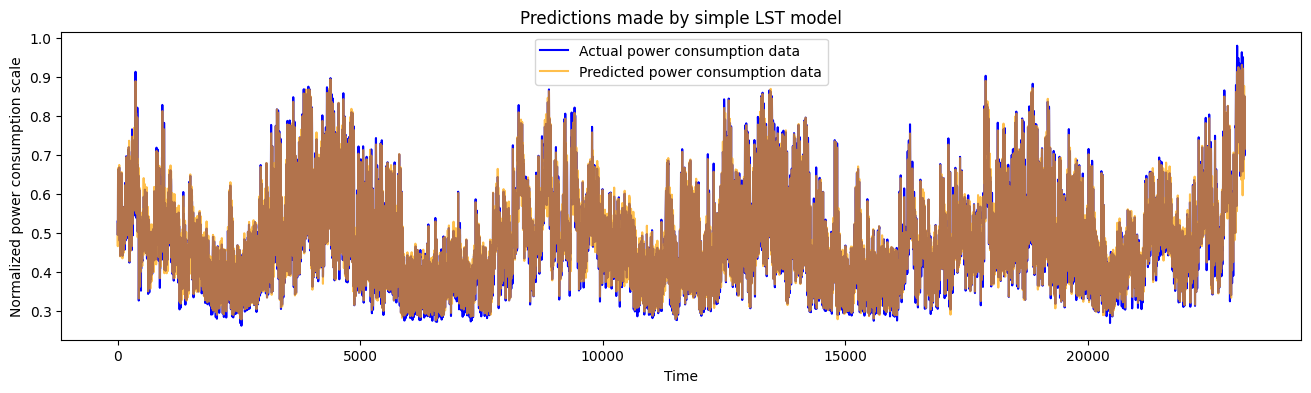

In [28]:
def plot_predictions(test, predicted, title):
    plt.figure(figsize=(16,4))
    plt.plot(test, color='blue',label='Actual power consumption data')
    plt.plot(predicted, alpha=0.7, color='orange',label='Predicted power consumption data')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Normalized power consumption scale')
    plt.legend()
    plt.show()
    
plot_predictions(y_test, lstm_predictions, "Predictions made by simple LST model")

In [29]:
!pip install shap

  Using cached tqdm-4.68.3-py3-none-any.whl.metadata (57 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 4.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------------------ --------------------- 1.3/2.8 MB 6.1 MB/s eta 0:00:01
   ------------------------------------- -- 2.6/2.8 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 6.0 MB/s  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.6/41.9 MB 8.3 MB/s eta 0:00:05
   -- ------------------------------------- 2.6/41.9 MB 6.3 MB/s eta 0:00:07
   --- ------------------------------------ 3.7/41.9 MB 6.1 MB/s eta 0:00:07
   ---- ----------------------------------- 4.7/41.9 MB 5.8 MB/s eta 0:00:07
   ----- ---------------------------------- 5.8/41.

727/727 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


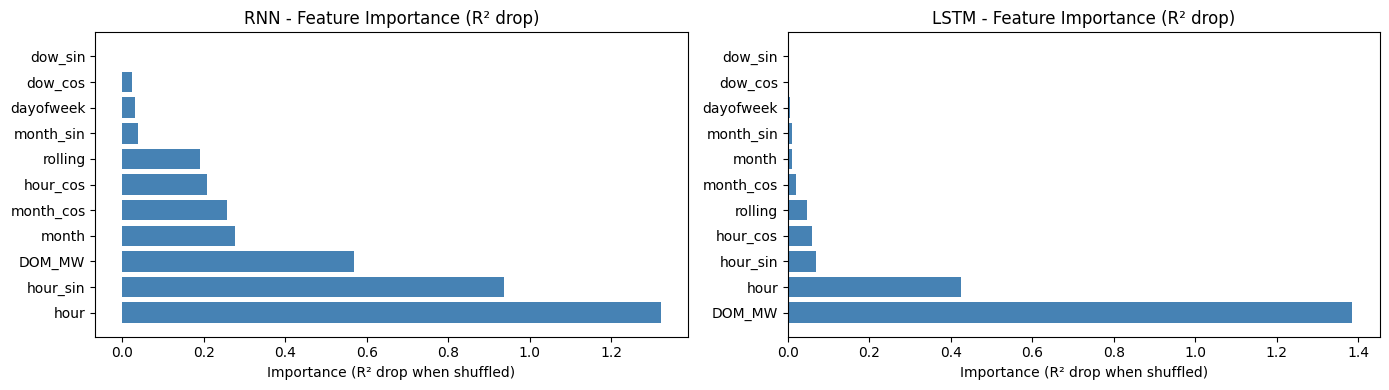

In [30]:
import numpy as np
from sklearn.metrics import r2_score

feature_names = df.columns.tolist()   # ['DOM_MW','hour','dayofweek','month','weekofyear']

def permutation_importance(model, X_test, y_test, feature_names):
    baseline = r2_score(y_test, model.predict(X_test))
    importances = {}
    for i, feat in enumerate(feature_names):
        X_perm = X_test.copy()
        np.random.shuffle(X_perm[:, :, i])   # shuffle feature i across all timesteps
        score = r2_score(y_test, model.predict(X_perm))
        importances[feat] = baseline - score  # drop = importance
    return importances

rnn_imp = permutation_importance(rnn_model, X_test, y_test, feature_names)
lstm_imp = permutation_importance(lstm_model, X_test, y_test, feature_names)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, imp, title in zip(axes, [rnn_imp, lstm_imp], ['RNN', 'LSTM']):
    sorted_imp = dict(sorted(imp.items(), key=lambda x: x[1], reverse=True))
    ax.barh(list(sorted_imp.keys()), list(sorted_imp.values()), color='steelblue')
    ax.set_title(f'{title} - Feature Importance (R² drop)')
    ax.set_xlabel('Importance (R² drop when shuffled)')
plt.tight_layout()
plt.show()

727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step
727/727 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step


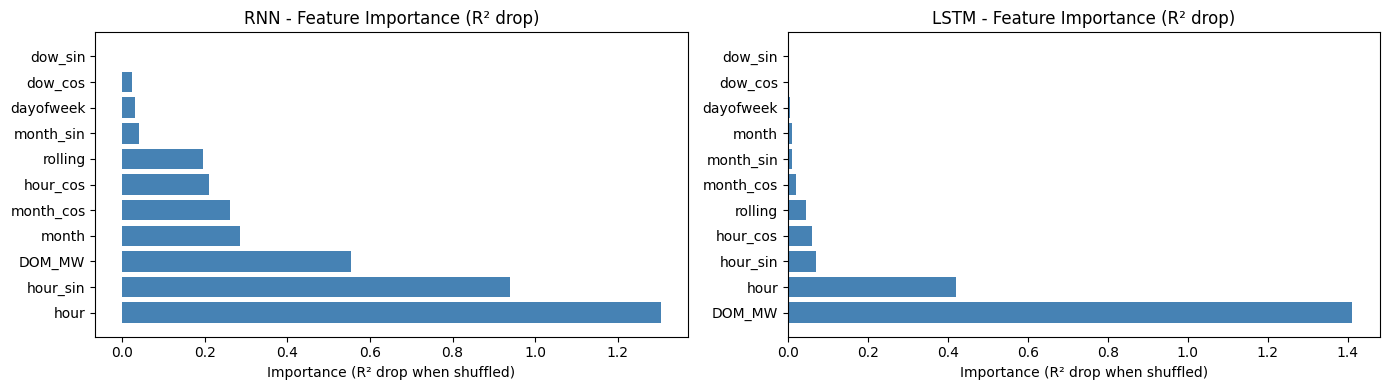

In [31]:
import numpy as np
from sklearn.metrics import r2_score

feature_names = df.columns.tolist()   # ['DOM_MW','hour','dayofweek','month','weekofyear']

def permutation_importance(model, X_test, y_test, feature_names):
    baseline = r2_score(y_test, model.predict(X_test))
    importances = {}
    for i, feat in enumerate(feature_names):
        X_perm = X_test.copy()
        np.random.shuffle(X_perm[:, :, i])   # shuffle feature i across all timesteps
        score = r2_score(y_test, model.predict(X_perm))
        importances[feat] = baseline - score  # drop = importance
    return importances

rnn_imp = permutation_importance(rnn_model, X_test, y_test, feature_names)
lstm_imp = permutation_importance(lstm_model, X_test, y_test, feature_names)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, imp, title in zip(axes, [rnn_imp, lstm_imp], ['RNN', 'LSTM']):
    sorted_imp = dict(sorted(imp.items(), key=lambda x: x[1], reverse=True))
    ax.barh(list(sorted_imp.keys()), list(sorted_imp.values()), color='steelblue')
    ax.set_title(f'{title} - Feature Importance (R² drop)')
    ax.set_xlabel('Importance (R² drop when shuffled)')
plt.tight_layout()
plt.show()